# Regression - Excercise

```In this exercise you will experience with simple features of the linear and logistic regressions, and will get to know some interesting features of those regressions.```

~```Ittai Haran```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

## Coefficients and some more

```We will start by exploring several concepts regarding linear and logistic regression. To that matter, we will prefer working using a generated dataset. Start by generating (using numpy and np.random) the following dataset:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = 0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] + 1$

```Generate 1,000 samples.```

In [ ]:
x = np.random.normal(0, 1, (1000, 3))
y = 0.3 * x[:, 0] + 0.5 * x[:, 1] - 0.7 * x[:, 2] + 1


array([[ 3.42713837,  0.9759488 ,  0.66669515],
       [-1.05854292,  1.89758083,  0.57088128],
       [-1.11668157, -0.2407449 ,  0.03779519],
       ...,
       [-1.25891214,  1.06894212,  2.26992323],
       [-0.94929008,  0.1536894 , -0.53366081],
       [-1.74308149,  0.46824587, -1.28220767]])

```Train a simple linear regression (sklearn.linear_model.LinearRegression) on the data. What coefficients did you get using your regression? Did you expect those coefficients?```

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

coefficients = model.coef_  
intercept = model.intercept_

print("coefficients:", coefficients)
print("bias:", intercept)
#זה צפוי כי כל הדטה יוצר בצורה ליניאאית ללא רעש

coefficients: [ 0.3  0.5 -0.7]
bias: 1.0


```We will now conduct a similar experiment, only this time using logistic regression, with minor adjustments:```

$X \sim \cal N(0,1)^3$ ```(i.e X consists of 3-dimensional vectors)```

$Y = (0.3\cdot X[:,0] + 0.5\cdot X[:,1] - 0.7\cdot X[:,2] \geq 1)$

```Generate 1,000 samples.```

In [89]:

x = np.random.normal(0, 1, (1000, 3))

y = 0.3 * x[:, 0] + 0.5 * x[:, 1] - 0.7 * x[:, 2] >= 0



```Train a simple logistic regression (sklearn.linear_model.LogisticRegression) on the data. What coefficients did you get using your logistic regression? Did you expect those coefficients? Why, or why not?```

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(x, y)

model.coef_  



array([[ 2.67413102,  4.57359228, -6.56614662]])

```Repeat this experiment, this time with 10,000 samples and 100,000 samples. Did you get different coefficients? Why or why not?```

In [126]:

for n_samples in [1000, 10000, 100000]:
    np.random.seed(42)

    x = np.random.normal(0, 1, (n_samples, 3))
    y = 0.3 * x[:, 0] + 0.5 * x[:, 1] - 0.7 * x[:, 2] >= 0

    
    model = LogisticRegression(random_state=42)
    model.fit(x, y)

    print(f"Samples: {n_samples} | Coefficients: {model.coef_} | Intercept: {model.intercept_}")
    for i in range(3):
        predicted_y = np.dot(x[i], model.coef_.T) + model.intercept_
        print(f"Sample {i+1}: X = {x[i]} | Predicted Y = {predicted_y}")



Samples: 1000 | Coefficients: [[ 2.74736387  4.86615718 -6.65670094]] | Intercept: [0.03422103]
Sample 1: X = [ 0.49671415 -0.1382643   0.64768854] | Predicted Y = [-3.58540918]
Sample 2: X = [ 1.52302986 -0.23415337 -0.23413696] | Predicted Y = [4.6376908]
Sample 3: X = [ 1.57921282  0.76743473 -0.46947439] | Predicted Y = [11.23250186]
Samples: 10000 | Coefficients: [[  6.18158131  10.27632142 -14.32671314]] | Intercept: [0.00817387]
Sample 1: X = [ 0.49671415 -0.1382643   0.64768854] | Predicted Y = [-7.6214435]
Sample 2: X = [ 1.52302986 -0.23415337 -0.23413696] | Predicted Y = [10.37108444]
Sample 3: X = [ 1.57921282  0.76743473 -0.46947439] | Predicted Y = [24.38263709]
Samples: 100000 | Coefficients: [[ 13.29485658  22.1993198  -31.07387946]] | Intercept: [0.0268361]
Sample 1: X = [ 0.49671415 -0.1382643   0.64768854] | Predicted Y = [-16.56498947]
Sample 2: X = [ 1.52302986 -0.23415337 -0.23413696] | Predicted Y = [22.35279754]
Sample 3: X = [ 1.57921282  0.76743473 -0.46947439

## Non-linear linear regressions

```Load the data in func_1_train.csv.
Can be found in: https://drive.google.com/open?id=1y3HtVk0N1q4xYn_qczDcdkZfGpy23z9l```

In [159]:
df = pd.read_csv('func_1_train.csv')

```Draw a scatter plot of y as a function of x. What kind of functions would you like to fit here?```

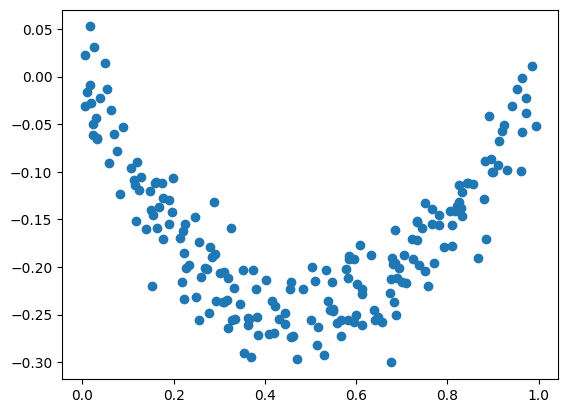

In [130]:
plt.scatter(df['x'], df['y'])

```Try fitting a linear regression. Draw the data points and the function you fitted on the same plot.```

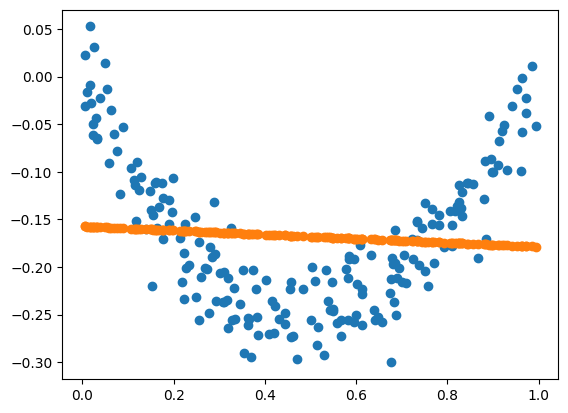

In [143]:
model = LinearRegression()
model.fit(df['x'].values.reshape(-1,1), df['y'])

plt.scatter(df['x'], df['y'])
plt.scatter(df['x'], model.predict(df['x'].values.reshape(-1,1)))

```Let's do some feature extraction. Create a dataset with the features (X, X**2, X**3, ..., X**49). Now try fitting a linear regression using your new dataset. Draw your results on the same graph as before. Judge your results using func_1_test and using the mean squared error metric.```

```Can be found in: https://drive.google.com/open?id=1ipm09QTjVZWFgh-zc70rxWLGPWYEt1Kb```

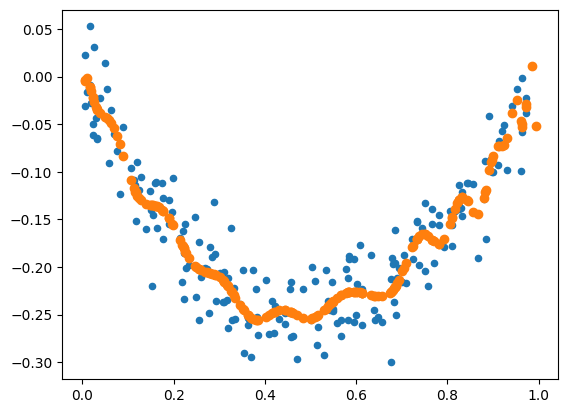

In [164]:
df_new = df.copy()
df_y= df_new['y']
df_new.drop(columns='y', inplace=True)
for i in range(2, 50):
    df_new['x' + str(i)] = df_new['x'].apply(lambda x: x**i)

model.fit(df_new,df_y)



y_pred = model.predict(df_new)

plt.scatter(df['x'], df['y'], s=20)
plt.scatter(df['x'], y_pred)

0.002986754381167288
0.0008289288320566686


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


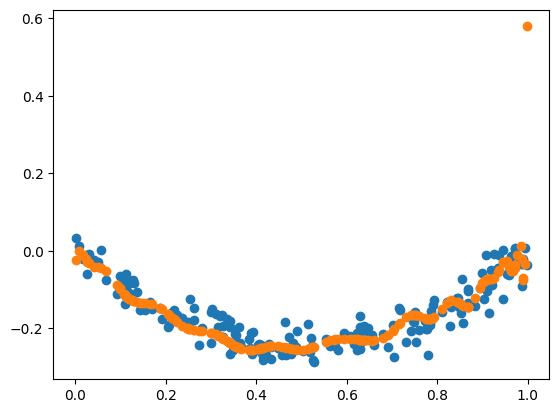

In [173]:
from sklearn.metrics import mean_squared_error

df_test = pd.read_csv('func_1_test.csv')
for i in range(2, 50):
    df_test['x_' + str(i)] = df_test['x'].apply(lambda x: x**i)


plt.scatter(df_test['x'], df_test['y'])
plt.scatter(df_test['x'], model.predict(df_test.drop(columns='y').values))

print(mean_squared_error(df_test['y'], model.predict(df_test.drop(columns='y').values)))
print(mean_squared_error(df_y, y_pred))



```How come you could a model that isn't under fitted? You did still use a linear regression. Can you explain those results? However, your model seemed to be over fitted (why?). Why is that?```

In [ ]:
#גם מודל לינראי יכול לתת תוצאות טובות במקרה כזה
# יש מעט אובר פיטינג כי נתנו למודל ללמוד בדיוק את הנתןנים ללא שום רגולרזציה או הגבלת הפיצרים

```You can try using a regularized regression to avoid over fitting. Use sklearn.linear_model.Ridge with different alphas until you get nice fit (judge it using your plots and using func_1_test and the mean squared error metric). Could you get better results?```

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


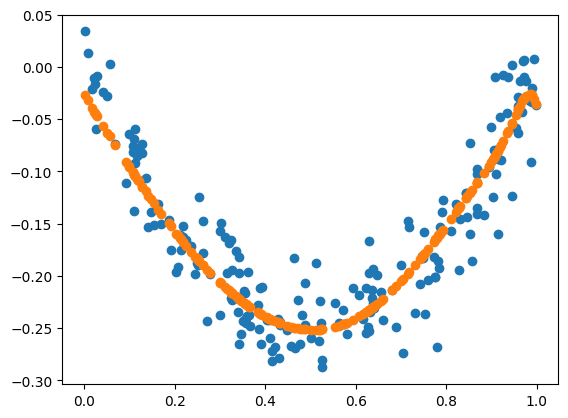

In [190]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.05)
ridge.fit(df_new,df_y)

plt.scatter(df_test['x'], df_test['y'])
plt.scatter(df_test['x'], ridge.predict(df_test.drop(columns='y').values))


## Working on a real life data

```Start by loading house_data.csv. For our current purposes we will need only the numeric columns. Take only the numeric columns, using pandas.DataFrame.dtypes. Use fillna(0) to get rid of nans (the the column Id. can tell why?).```

```Can be found in: https://drive.google.com/open?id=1ID2h8mzjXLRbay5pE0QN1v5-jc86203L```

In [225]:
df = pd.read_csv('house_data.csv')

numeric_df = df.select_dtypes(include=['number'])
numeric_df.fillna(0, inplace=True)
numeric_df.drop('Id',axis=1, inplace=True)

print(numeric_df.isnull().values.any())  

#מספר זהות לא משפיע כלום ורק יבלבל את המודל

False


```We would like to predict the SalePrice columns. Create, using your data, the features dataset and the target dataset. Use sklearn.model_selection.train_test_split and create a train segment of 0.7 of your data and test segment of 0.3 of your data.```

In [226]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(numeric_df.drop(columns='SalePrice'), numeric_df['SalePrice'], train_size=0.7)



```Try fitting the best linear regression you can (evaluate yourself using mean squared error). You can also use ridge regression with different alphas.```

In [228]:
reg1 = LinearRegression()
reg1.fit(train_X, train_Y)
print('mse: ', mean_squared_error(test_Y, reg1.predict(test_X)))


mse:  1264056988.18435


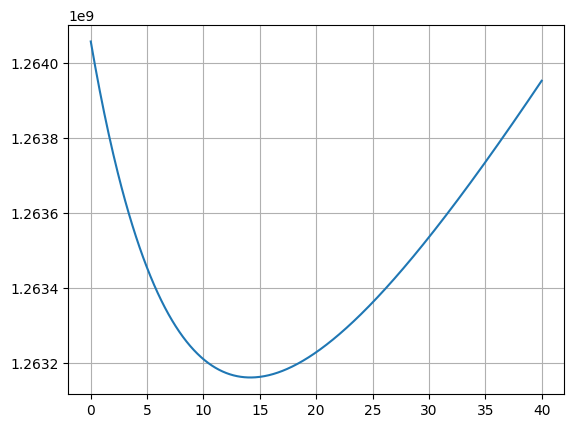

optimal alpha = 14.18844128256513
best mse = 1263160642.588451


In [238]:

mses = []

alphas = np.linspace(0.0001, 40, 500)

for alpha in alphas:
    ridge = Ridge(alpha)
    ridge.fit(train_X, train_Y)
    mses.append(mean_squared_error(test_Y, ridge.predict(test_X)))

plt.plot(alphas, mses, label="MSE")
plt.grid(True)
plt.show()

ridge = Ridge(alphas[np.argmin(mses)])
ridge.fit(train_X, train_Y)
print(f"optimal alpha = {alphas[np.argmin(mses)]}")
print(f"best mse = {mean_squared_error(test_Y, ridge.predict(test_X))}")


```If you would look closely, you will find out that you dropped the columns LotShape and LandContour. This time try not dropping them, and instead replace them with a 1-hot encoding of them (consider``` [pandas.get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html))```.
Try getting better results on the test segment using your ridge regressions. compare the new results with the old ones.```

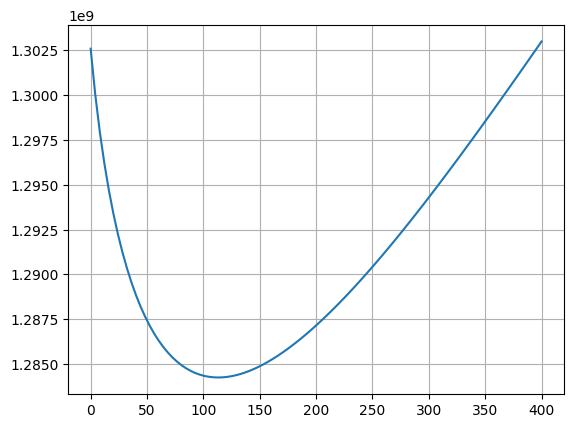

optimal alpha = 113.13138484848486
best mse = 1284268488.7160044


In [242]:

df = pd.read_csv('house_data.csv')
df = pd.get_dummies(df, columns=['LotShape', 'LandContour'], drop_first=True)

numeric_df = df.select_dtypes(include=['number'])
numeric_df.fillna(0, inplace=True)
numeric_df.drop('Id',axis=1, inplace=True)

train_X, test_X, train_Y, test_Y = train_test_split(numeric_df.drop(columns='SalePrice'), numeric_df['SalePrice'], train_size=0.7)


mses = []

alphas = np.linspace(0.0001, 400, 100)

for alpha in alphas:
    ridge = Ridge(alpha)
    ridge.fit(train_X, train_Y)
    mses.append(mean_squared_error(test_Y, ridge.predict(test_X)))

plt.plot(alphas, mses, label="MSE")
plt.grid(True)
plt.show()

ridge = Ridge(alphas[np.argmin(mses)])
ridge.fit(train_X, train_Y)
print(f"optimal alpha = {alphas[np.argmin(mses)]}")
print(f"best mse = {mean_squared_error(test_Y, ridge.predict(test_X))}")



```Now add more features to your dataframe:```
- ```LotArea in squared meters ( it's currently in units of squared feet)```
- ```1stFlrSF + 2ndFlrSF```
- ```GarageArea**0.5```
- ```LotArea / (BedroomAbvGr+1)```
- ```LotArea / (mean LotArea for houses built in that same year + 1e-5) - you might want to use``` [pandas merge function](https://www.google.com/search?q=pandas+merge&oq=pandas+merge&aqs=chrome..69i57l2j69i59l3j69i60.2080j0j9&sourceid=chrome&ie=UTF-8)
- ```Ranking of LotArea (largest house has 1, the second largest has 2 and so on)```
- ```One hot encoding of LotConfig```

```Are they improve the results?.```

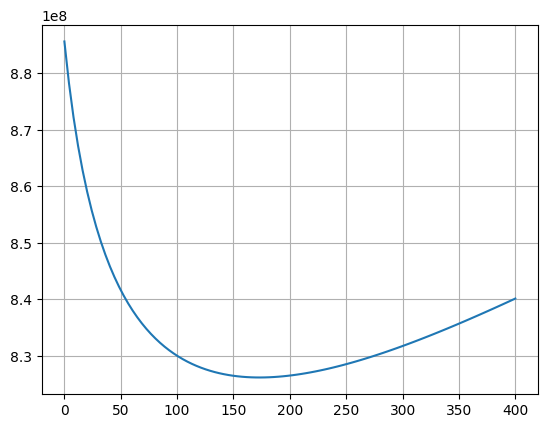

optimal alpha = 173.73743030303032
best mse = 826220594.8486344


In [243]:
df = pd.read_csv('house_data.csv')

df['LotArea_m2'] = df['LotArea'] / 10.764

df['TotalFlrSF'] = df['1stFlrSF'] + df['2ndFlrSF']

df['GarageArea_sqrt'] = df['GarageArea'] ** 0.5

df['LotArea_per_bed'] = df['LotArea'] / (df['BedroomAbvGr'] + 1)

mean_lot_area_by_year = df.groupby('YearBuilt')['LotArea'].transform('mean')
df['LotArea_to_year_mean'] = df['LotArea'] / (mean_lot_area_by_year + 1e-5)

df['LotArea_rank'] = df['LotArea'].rank(ascending=False)

df.drop(['LotArea', '1stFlrSF', '2ndFlrSF', 'GarageArea', 'BedroomAbvGr'], axis=1, inplace=True)


df = pd.get_dummies(df, columns=['LotConfig'], drop_first=True)

numeric_df = df.select_dtypes(include=['number'])
numeric_df.fillna(0, inplace=True)
numeric_df.drop('Id',axis=1, inplace=True)

train_X, test_X, train_Y, test_Y = train_test_split(numeric_df.drop(columns='SalePrice'), numeric_df['SalePrice'], train_size=0.7)


mses = []

alphas = np.linspace(0.0001, 400, 100)

for alpha in alphas:
    ridge = Ridge(alpha)
    ridge.fit(train_X, train_Y)
    mses.append(mean_squared_error(test_Y, ridge.predict(test_X)))

plt.plot(alphas, mses, label="MSE")
plt.grid(True)
plt.show()

ridge = Ridge(alphas[np.argmin(mses)])
ridge.fit(train_X, train_Y)
print(f"optimal alpha = {alphas[np.argmin(mses)]}")
print(f"best mse = {mean_squared_error(test_Y, ridge.predict(test_X))}")

## Bonus

```Think of a feature of your own that improve the result.```

In [ ]:
#לעשות OHE לעוד שדות
# לחשב גיל בית
# לחלק לפי שכונה 

```Use KNN regression (sklearn.neighbors.KNeighborsRegressor).
Compare the results to the linear regression.```